##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** [Be Right Back]

**Student names & numbers:**
* [Rick de Cuijper] - [Student no.100097]
* [Bart Geijtenbeek] - [Student no.97543]
* [Boaz Vaneveld] - [Student no.101529]


---

## 0. Iteration setup

**Import libraries**

In [109]:
# CODE CELL: import the necessary libraries for this iteration

import pandas as pd;
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder



**Load and merge datasets**

In [110]:
# CODE CELL: import the necessary datasets for this iteration
# Make sure to load your cleaned dataset from Iteration 1 AND the new inspection data for Iteration 2.
# Merge them together based on the Ship_ID.

df_ships1 = pd.read_csv("ships_inventory_iter1_clean.csv")
df_ships1.head(5)

,Unnamed: 0,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Model_Cycle_Clean,Galactic_Credits_Clean,Is_Outlier
0,0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,7505.0,4950,False
1,1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,7518.0,18999,False
2,2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,7486.0,4000,False
3,3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,7511.0,6495,False
4,4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,7499.0,3995,False


In [111]:
df_ships2 = pd.read_csv("ship_inspections_iter2.csv")
df_ships2.head(5)

,Ship_ID,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
0,7316814884,Operational,80.0,Ion Drive,Hauler
1,7316814758,Operational,80.0,Hyperdrive,Hauler
2,7316814989,Pristine,80.0,Hyperdrive,Hauler
3,7316743432,Pristine,80.0,Plasma Thruster,Hauler
4,7316356412,Operational,60.0,Ion Drive,Freighter


In [112]:
# Data set are joining
df_merged = df_ships1.merge(df_ships2, left_on='Ship_ID', right_on='Ship_ID', how='left')
df_merged.head(5)


,Unnamed: 0,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Model_Cycle_Clean,Galactic_Credits_Clean,Is_Outlier,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
0,0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,7505.0,4950,False,Critical,40.0,Ion Drive,Shuttle
1,1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,7518.0,18999,False,Pristine,120.0,Solar Sail,Shuttle
2,2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,7486.0,4000,False,Critical,40.0,Ion Drive,Shuttle
3,3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,7511.0,6495,False,Pristine,40.0,Graviton Beam,Shuttle
4,4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,7499.0,3995,False,Critical,40.0,Hyperdrive,Shuttle


We used left join to keep previous data intact without introducing more unknown data or removing any existing rows.

---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**
*Describe the problem surrounding the safety inspections. Why is the current process (human estimation/gut feeling) a risk?*

Nebula Brokerage has recieved new date about their inventory of ships, this data is however recorded in a new seperate data file. The data has large gaps in propulsion types due to broken sensors and there is a rumor that there are illegal overclocked reactors. going on gut feeling during the sale could lead to the company selling illegal ships or the wrong propulsion type to a custommer.

**Business objective(s)**
*Justify why a standardized, rule-based expert system is needed.*

we need to build a model that fills in the gaps in the data using other data to make the best posible prediction of what the data should look like.
our model also needs to easily indicate if a ship has illegal overclocked reactors.

**Data mining goal(s)**
*Explain what type of modeling task this is and why.*

This problem involves two modeling tasks:

Classification 
- The goal is to predicts the Hull_Condition for each ship.
- The model will learn patterns from known ship attributes: (Ship_Manufacturer, Reactor_Power, propulsion type)

Data Imputation / Prediction 
- The dataset contains missing propulsion types, which must be inferred.
- This is data preparation task.

**Success criteria**
*Determine success criteria for this iteration*

**Model Performance**
Classification model achieves ≥ 75% accuracy and overall good scores

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

In [113]:
# CODE CELL: Show basic statistics and information
df_merged.info()
df_merged.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368314 entries, 0 to 368313
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Unnamed: 0              368314 non-null  int64  
 1   Ship_ID                 368314 non-null  int64  
 2   Galactic_Credits        368314 non-null  int64  
 3   Model_Cycle             360916 non-null  float64
 4   Ship_Manufacturer       368314 non-null  object 
 5   Sector                  368314 non-null  object 
 6   Model_Cycle_Clean       368314 non-null  float64
 7   Galactic_Credits_Clean  368314 non-null  int64  
 8   Is_Outlier              368314 non-null  bool   
 9   Hull_Integrity          368314 non-null  object 
 10  Reactor_Power           338876 non-null  float64
 11  Propulsion_Type         311704 non-null  object 
 12  Ship_Class              368314 non-null  object 
dtypes: bool(1), float64(3), int64(4), object(5)
memory usage: 34.1+ MB


,Unnamed: 0,Ship_ID,Galactic_Credits,Model_Cycle,Model_Cycle_Clean,Galactic_Credits_Clean,Reactor_Power
count,368314.000000,3.683140e+05,368314.000000,360916.000000,368314.000000,368314.000000,338876.000000
mean,184360.748147,7.311484e+09,19454.237615,7511.263984,7511.298854,19309.895586,71.592559
std,106475.762442,4.381194e+06,15542.661057,9.079721,8.991369,14364.950258,44.644147
min,0.000000,7.301583e+09,501.000000,7400.000000,7400.000000,501.000000,30.000000
25%,92143.250000,7.308103e+09,7950.000000,7508.000000,7508.000000,7950.000000,40.000000
50%,184337.500000,7.312604e+09,15990.000000,7513.000000,7513.000000,15990.000000,60.000000
75%,276576.750000,7.315244e+09,27990.000000,7517.000000,7517.000000,27990.000000,80.000000
max,368813.000000,7.317101e+09,777777.000000,7522.000000,7522.000000,78000.000000,360.000000


there are 4 new rows of data added with the second data set.

Hull_Integrity, a string that represents the condition of the hull of the ship (prestine, operational and critical).
important for quicly understanding the condition the ship is in.

Reactor_Power, a number representing how powerfull the ships reactor is.
a large diviation in this number could indicate problems such as overclocking.

Propulsion type, what propulsion the shup uses.
general data about the ships with large gaps due to a sensor mallfunction.

Ship class, what the ship is used for.
usefull to know for buyers.


**Visualizations and patterns**

*Discover patterns in the data that will help you determine the inspection rules. Create visualizations that show the relationship between variables like Reactor_Power, Propulsion_Type, Ship_Class on one side, and the target variable Hull_Integrity on the other. Describe any hard rules you discover (e.g., relationships with dangerous reactors or advanced tech).*

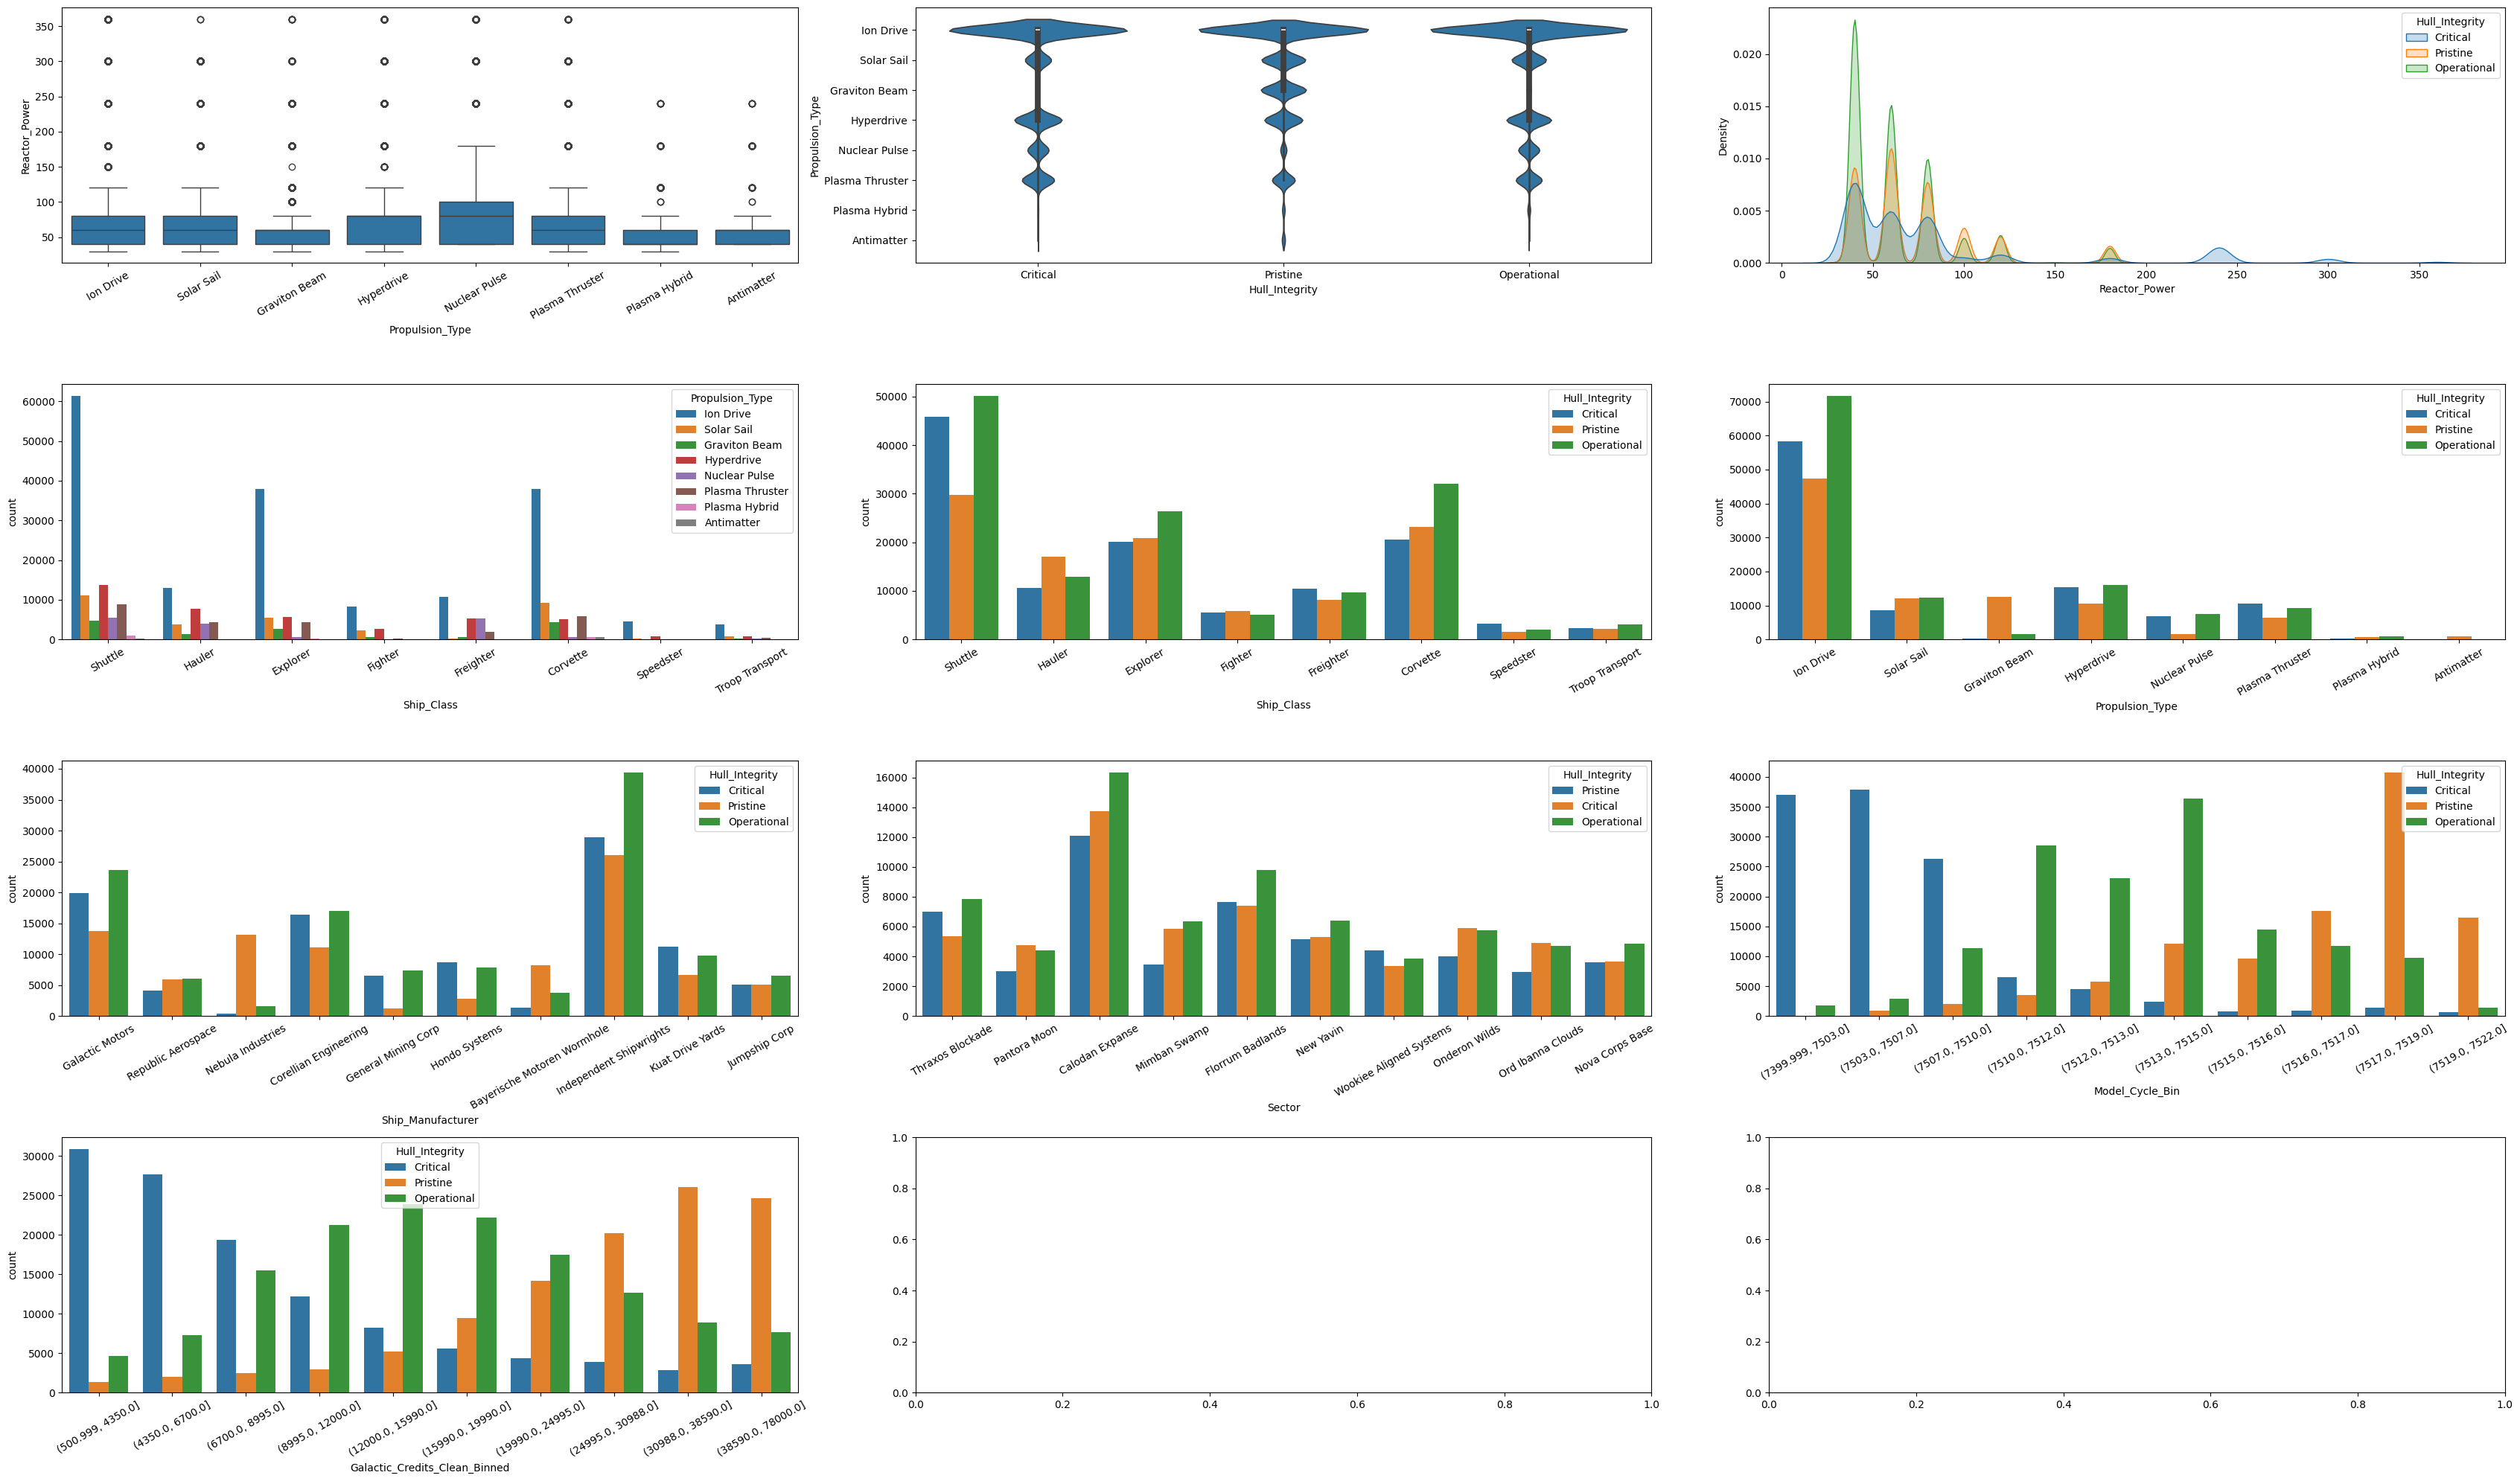

In [114]:
# CODE CELL: Generate visualizations (e.g., bar charts, boxplots comparing features against Hull_Integrity)
fig, axes = plt.subplots(4, 3, figsize=(34, 20))

# Row 1
sns.boxplot(x='Propulsion_Type', y='Reactor_Power', data=df_merged, ax=axes[0, 0])
axes[0, 0].tick_params(axis='x', rotation=30)

sns.violinplot(x='Hull_Integrity', y='Propulsion_Type', data=df_merged, ax=axes[0, 1])

sns.kdeplot(data=df_merged, x='Reactor_Power', hue='Hull_Integrity', fill=True, ax=axes[0, 2])

# Row 2
sns.countplot(data=df_merged, x="Ship_Class", hue="Propulsion_Type", ax=axes[1, 0])
axes[1, 0].tick_params(axis='x', rotation=30)

sns.countplot(data=df_merged, x="Ship_Class", hue="Hull_Integrity", ax=axes[1, 1])
axes[1, 1].tick_params(axis='x', rotation=30)

sns.countplot(data=df_merged, x="Propulsion_Type", hue="Hull_Integrity", ax=axes[1, 2])
axes[1, 2].tick_params(axis='x', rotation=30)

# Row 3
top_manufacturers = df_merged["Ship_Manufacturer"].value_counts().nlargest(10).index
df_top = df_merged[df_merged["Ship_Manufacturer"].isin(top_manufacturers)]
sns.countplot(data=df_top, x="Ship_Manufacturer", hue="Hull_Integrity", ax=axes[2, 0])
axes[2, 0].tick_params(axis='x', rotation=30)

top_sectors = df_merged["Sector"].value_counts().nlargest(10).index
df_top_Sector = df_merged[df_merged["Sector"].isin(top_sectors)]
sns.countplot(data=df_top_Sector, x="Sector", hue="Hull_Integrity", ax=axes[2, 1])
axes[2, 1].tick_params(axis='x', rotation=30)

df_merged["Model_Cycle_Bin"] = pd.qcut(df_merged["Model_Cycle_Clean"], q=10)
sns.countplot(data=df_merged, x="Model_Cycle_Bin", hue="Hull_Integrity", ax=axes[2, 2])
axes[2, 2].tick_params(axis='x', rotation=30)

# Row 4

df_merged["Galactic_Credits_Clean_Binned"] = pd.qcut(df_merged["Galactic_Credits_Clean"], q=10)
sns.countplot(data=df_merged, x="Galactic_Credits_Clean_Binned", hue="Hull_Integrity", ax=axes[3, 0])
axes[3, 0].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Data Insights and Data Quality

### Observations

Graph 1 and 3 show that most vehicles have lower engine power, so high power could indicate overclocking. ships over 200 power seem to always be in critical condition.

Graph 2, 5 and 6 show that Shuttels and Ion drives show more wear and have less pristine moddels. Graviton beams and haulers show less wean and more pristine options.

Graph 4 shows that Ion beams are by far the most popular propulsion type and that Shuttles, Explorers and Corvettes are the most popular ship classes.

Graph 7, 8, 9 were added because the current model was underfit and these new graphs have added value because 7 shows that Nebula industries and Honda systems are very pristine and that ... Motoren wormhole are most operational. graph 8 is kinda useless and graph 9 i9s super valueble and easely appied in our model. because 0 to 7510 are mostly critical and 7510 to 7516 are mostly operational and > 7516 is mostly pristine.

Graph 10 shows that there could be a overlap in data with model_cycle_clean and galectic_credits_clean witch could be usefull to the model

### Insights
- **Engine Power**
  - Most ships have low power levels  
  - Ships with **power > 200** are usually in **critical condition** have possible indicator of overclocked reactors  

- **Ship Class & Propulsion**
  - **Shuttles** and **Ion drives** have more wear, fewer pristine ships  
  - **Haulers** and **Graviton beams** have less wear, more pristine ships  

- **Popularity**
  - **Ion propulsion** is most common  
  - Most common ship classes: **Shuttles, Explorers, Corvettes**  

### Data Quality Issues
- **Missing Values**
  - Large gaps in **Propulsion** and **Reactor** data  
  - Can reduce accuracy and introduce bias  

- **Bias**
  - Possible overrepresentation of: Low-power ships and Ion propulsion  

- **Outliers**
  - Ships with **power > 200** are clear outliers  
  - Likely linked to **overclocking** or data errors  

### Conclusion
Strong patterns exist for **classification (overclocking detection)**  

Missing data and bias must be handled carefully to ensure reliable results

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify how you resolve the missing values.*

                 Missing Count  Missing (%)
Reactor_Power            29438     7.992637
Propulsion_Type          56610    15.370038


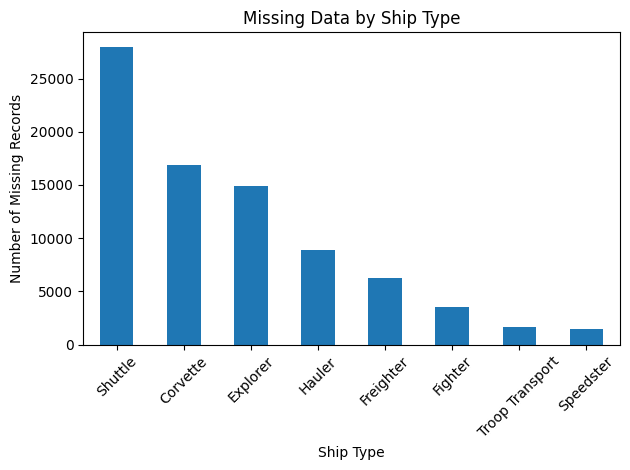

In [116]:
# CODE CELL: Preproccessing
cols = ['Reactor_Power', 'Propulsion_Type']

missing_count = df_merged[cols].isnull().sum()

# 2. Percentage of missing values
missing_percentage = (df_merged[cols].isnull().sum() / len(df_merged)) * 100

# combine into one table
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing (%)': missing_percentage
})

print(missing_summary)

# create a flag for rows with missing Reactor OR Propulsion
df_merged['Missing'] = df_merged[['Reactor_Power', 'Propulsion_Type']].isnull().any(axis=1)

# count missing per ship type
missing_by_type = (
    df_merged[df_merged['Missing']]
    .groupby('Ship_Class')
    .size()
    .sort_values(ascending=False)
)

# plot
plt.figure()
missing_by_type.plot(kind='bar')
plt.xlabel('Ship Type')
plt.ylabel('Number of Missing Records')
plt.title('Missing Data by Ship Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This graph demonstrates that simply filling in missing data without using group-based imputation can introduce significant bias. In particular, categories such as shuttles, corvettes, and explorers may become overrepresented.

As a result, the dataset would no longer accurately reflect the true distribution, which could ultimately make the model unreliable or ineffective.

To address this, we used this insight to avoid introducing bias into the dataset by applying more appropriate, group-based data filling methods.

This graph is not part of the dataset adjustment process. Instead, it is used as a validation tool to ensure that data preparation was carried out correctly and without introducing bias, as mentioned above.

In [117]:
# CODE CELL: Data cleaning
# 1 reactor power missing values
df_merged['Reactor_Power_Clean'] = df_merged.groupby('Ship_Class')['Reactor_Power']\
                       .transform(lambda x: x.fillna(x.median()))

df_merged['Propulsion_Type_Clean'] = df_merged.groupby('Ship_Class')['Propulsion_Type']\
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))

# 2 reactor power outliers aren't wrong there features of checking if reactores are overclocked
df_merged['Possible_Overclocked_reactor'] = df_merged['Reactor_Power_Clean'] > 200

# 3 observation / validation
print('amount of possible overclocked reactors:', df_merged['Possible_Overclocked_reactor'].sum())
print('missing values in propultion type cean:', df_merged['Propulsion_Type_Clean'].isnull().sum())
print('missing values in reactor power cleaned:', df_merged['Reactor_Power_Clean'].isnull().sum())

print((df_merged['Propulsion_Type_Clean']
       .value_counts(normalize=True) * 100)
       .round(2))


amount of possible overclocked reactors: 10152
missing values in propultion type cean: 0
missing values in reactor power cleaned: 0
Propulsion_Type_Clean
Ion Drive          63.53
Hyperdrive         11.40
Solar Sail          8.96
Plasma Thruster     7.11
Nuclear Pulse       4.40
Graviton Beam       3.88
Plasma Hybrid       0.49
Antimatter          0.23
Name: proportion, dtype: float64


## Summary of Findings and Data Preparation Decisions

The dataset initially contained missing values in both **Reactor Power** and **Propulsion Type**, which were addressed using **group-based imputation by Ship Class**. Reactor Power was filled using the median within each ship class, while Propulsion Type was filled using the most frequent value (mode) within each class. This approach preserves structural differences between ship types and avoids introducing global bias.

No missing values remain after preprocessing, indicating that the imputation strategy was successful in producing a complete dataset suitable for further analysis.

Outliers in Reactor Power (values above 200) were **not removed**. Instead, they were retained and explicitly flagged as potential overclocked reactors. This decision was made because these extreme values are not necessarily errors but may represent meaningful anomalies relevant to the business objective of detecting illegal or overclocked ships. Removing them would risk losing important signals needed for classification and anomaly detection.

Overall, the preprocessing strategy focused on preserving data integrity, maintaining meaningful variation in the dataset, and transforming anomalies into useful features rather than discarding them.


**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [118]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Build a manual classifier. Use the insights from step 2 to write a Python function with if/elif/else statements that predicts the Hull_Condition for each ship. Apply this function to your dataset and save the predictions in a new column.*

In [ ]:
# CODE CELL: Model training and setup code
# copy data
df = df_merged.copy()

# encode features
le_propulsion = LabelEncoder()
le_manufacturer = LabelEncoder()

df["Propulsion_enc"] = le_propulsion.fit_transform(df["Propulsion_Type"])
df["Manufacturer_enc"] = le_manufacturer.fit_transform(df["Ship_Manufacturer"])

df_merged["Propulsion_enc"] = le_propulsion.transform(df_merged["Propulsion_Type"])
df_merged["Manufacturer_enc"] = le_manufacturer.transform(df_merged["Ship_Manufacturer"])

# predict column
def predict(row):
    if row['Model_Cycle_Clean'] <= 7509.5:
        if row['Propulsion_enc'] <= 1.5:
            if row['Model_Cycle_Clean'] <= 7505.5:
                return 'Operational'
            else:
                return 'Pristine'
        else:
            if row['Manufacturer_enc'] <= 0.5:
                return 'Operational'
            else:
                return 'Critical'
    else:
        if row['Model_Cycle_Clean'] <= 7516.5:
            if row['Propulsion_enc'] <= 1.5:
                return 'Pristine'
            else:
                return 'Operational'
        else:
            if row['Galactic_Credits_Clean'] <= 20988.5:
                return 'Operational'
            else:
                return 'Pristine'
df_merged['Predicted_Hull_Integrity'] = df_merged.apply(predict, axis=1)

**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

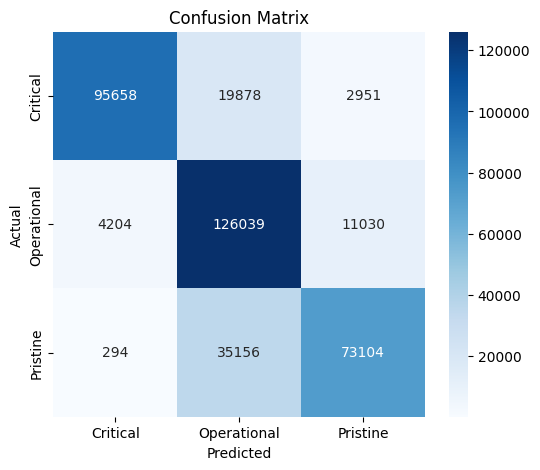

Accuracy: 0.8004067181806828

Classification Report:

              precision    recall  f1-score   support

    Critical       0.96      0.81      0.88    118487
 Operational       0.70      0.89      0.78    141273
    Pristine       0.84      0.67      0.75    108554

    accuracy                           0.80    368314
   macro avg       0.83      0.79      0.80    368314
weighted avg       0.82      0.80      0.80    368314



In [131]:
# CODE CELL: Model evaluation code

# Predict
test = df_merged['Hull_Integrity']
pred = df_merged['Predicted_Hull_Integrity']

# Confusion matrix
cm = confusion_matrix(test, pred)

# Plot
plt.figure(figsize=(6,5))
labels = np.unique(test)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("Accuracy:", accuracy_score(test, pred))
print("\nClassification Report:\n")
print(classification_report(test, pred))

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 

The model achieves an accuracy of 0.80 which means it correctly classifies about 80 percent of all ships. It performs very well on the Critical class with high precision indicating it is effective at identifying high risk ships and rarely misses them. The Operational and Pristine classes are less well distinguished with more overlap between them and lower recall for Pristine. Overall the model meets the main objective of detecting Critical ships but is less reliable for finer distinctions between Operational and Pristine.

**Key findings and limitations**

The rule based system relies on fixed thresholds and manually defined conditions which makes it inflexible and dependent on assumptions rather than learned patterns. It struggles to capture complex relationships between multiple features and cannot easily adapt to new or changing data. The model also requires manual tuning and does not improve automatically with more data. These limitations reduce its scalability and long term reliability.

One of the thing i found out when building the classiefier for iter3 is that with the sklearn.tree import _tree lib. i managed to convert my ai into a manual model allowing for the desision tree to define optimal logic while keeping the simplicity of a manual if/elif model.

**Why a machine learning model may be better**

A machine learning model can learn patterns directly from data and capture nonlinear relationships between features. It can adapt to new data more easily and typically provides better overall accuracy and class separation. It also reduces the need for manual rule creation and is better suited for handling complex interactions between variables.


Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset for the next iteration. 

In [ ]:
df_merged.to_csv('ships_inventory_iter1_leftJoin_iter2_clean.csv')

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Rick de Cuijper | *cleaned the dataset and made the model* | *I learned how to generate manually written classifier rules using from sklearn.tree import _tree, enabling a decision tree classifier to produce optimal logic and convert it into Python code using AI as intended. Like so: 'generated_code = tree_to_function(clf, features, clf.classes\_)'* |
| Boaz Vaneveld | *Contribution description* | *Personal lessons learned this iteration* |
| Bart Geijtenbeek | imported and merged data from iter1, made data understanding | *I learned how much care you need to put in merging and that there is a lot of information you can pull form just a few numbers in data understanding* |

In [ ]:
df_merged.to_csv('ships_merged.csv')